<a href="https://colab.research.google.com/github/Taeryoung06/AI_SOGANG_MiniProject/blob/master/FNN_NSMC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import json
import platform
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


def find_project_root():
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    for candidate in candidates:
        if (candidate / "Data" / "NSMC" / "ratings_train.txt").exists():
            return candidate
    for candidate in candidates:
        if (candidate / "XAI" / "Data" / "NSMC" / "ratings_train.txt").exists():
            return candidate
    raise FileNotFoundError("NSMC data files not found under Data/NSMC or XAI/Data/NSMC.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "Data" / "NSMC"
if not DATA_DIR.exists():
    DATA_DIR = PROJECT_ROOT / "XAI" / "Data" / "NSMC"

train_file_path = DATA_DIR / "ratings_train.txt"
test_file_path = DATA_DIR / "ratings_test.txt"

train_data = pd.read_csv(train_file_path, sep='\t')
test_data = pd.read_csv(test_file_path, sep='\t')

print(f'훈련용 리뷰 개수: {len(train_data)}')
print(f'테스트용 리뷰 개수: {len(test_data)}')

훈련용 리뷰 개수: 150000
테스트용 리뷰 개수: 50000


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


label
0    75173
1    74827
Name: count, dtype: int64


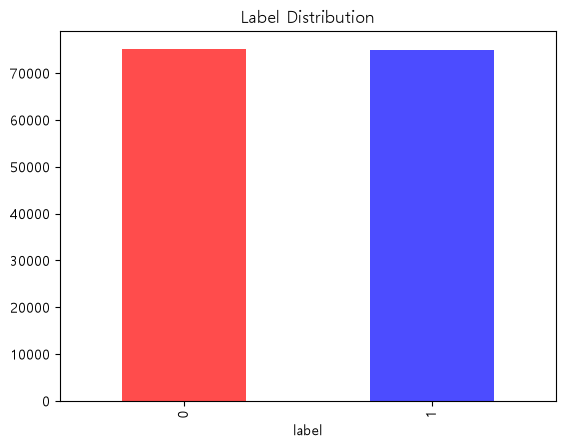

In [21]:
import matplotlib.pyplot as plt

display(train_data.head())

print(train_data['label'].value_counts())

train_data['label'].value_counts().plot(kind='bar', color=['red', 'blue'], alpha=0.7)
plt.title('Label Distribution')
plt.show()

In [22]:
train_data.drop_duplicates(subset=['document'], inplace=True)

print(f'중복 제거 후 훈련용 리뷰 개수: {len(train_data)}')
print(train_data.isnull().sum())

train_data = train_data.dropna(how='any')
print(f'결측치 제거 후 훈련용 리뷰 개수: {len(train_data)}')

중복 제거 후 훈련용 리뷰 개수: 146183
id          0
document    1
label       0
dtype: int64
결측치 제거 후 훈련용 리뷰 개수: 146182


In [23]:
import re

def clean_text(text):
    text = re.sub(r'[^ㄱ-ㅎㅏ-ㅣ가-힣 ]', '', text)
    return text

train_data['document'] = train_data['document'].apply(clean_text)

train_data['document'] = train_data['document'].replace('^ +', '', regex=True)
train_data['document'] = train_data['document'].replace('', pd.NA)

train_data = train_data.dropna(how='any')
print(f'텍스트 정제 후 최종 훈련용 리뷰 개수: {len(train_data)}')

텍스트 정제 후 최종 훈련용 리뷰 개수: 145393


In [24]:
!pip install konlpy
from konlpy.tag import Okt
from tqdm import tqdm

okt = Okt()

stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

X_train = []

for sentence in tqdm(train_data['document']):

    tokenized_sentence = okt.morphs(sentence, stem=True)

    stopwords_removed_sentence = [word for word in tokenized_sentence if not word in stopwords]
    X_train.append(stopwords_removed_sentence)

print(X_train[0])

100%|██████████| 145393/145393 [03:55<00:00, 616.59it/s]

['아', '더빙', '진짜', '짜증나다', '목소리']


In [25]:
from collections import Counter

words = [word for sentence in X_train for word in sentence]
vocab = Counter(words)

vocab_size = 10000
vocab = vocab.most_common(vocab_size)

word_to_index = {'<PAD>': 0, '<UNK>': 1}

for index, (word, _) in enumerate(vocab):
    word_to_index[word] = index + 2

print(f"단어장 크기: {len(word_to_index)}")

단어장 크기: 10002


In [26]:
X_train_encoded = []

for sentence in X_train:
    encoded_sentence = [word_to_index.get(word, word_to_index['<UNK>']) for word in sentence]
    X_train_encoded.append(encoded_sentence)

print(X_train_encoded[0])

[51, 455, 17, 261, 660]


리뷰의 최대 길이 : 72
리뷰의 평균 길이 : 11.001203634287759


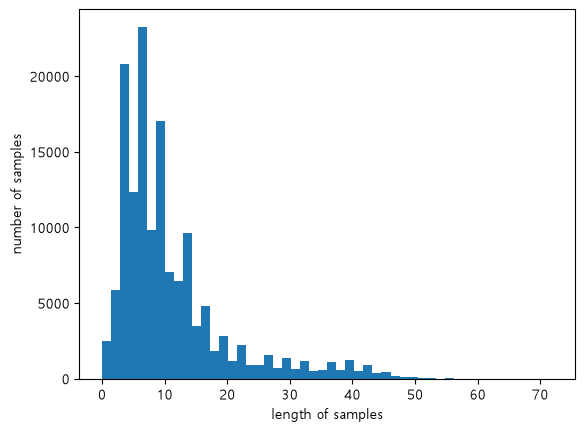

훈련 데이터의 최종 형태: (145393, 30)
레이블 데이터의 최종 형태: (145393,)


In [27]:
import numpy as np
import matplotlib.pyplot as plt

print('리뷰의 최대 길이 :', max(len(review) for review in X_train_encoded))
print('리뷰의 평균 길이 :', sum(map(len, X_train_encoded))/len(X_train_encoded))

plt.hist([len(review) for review in X_train_encoded], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

max_len = 30

def pad_sequences(sentences, max_len):
    features = np.zeros((len(sentences), max_len), dtype=int)

    for i, sentence in enumerate(sentences):
        if len(sentence) != 0:
            features[i, :len(sentence)] = np.array(sentence)[:max_len]

    return features

X_train_padded = pad_sequences(X_train_encoded, max_len)
y_train = np.array(train_data['label'])

print("훈련 데이터의 최종 형태:", X_train_padded.shape)
print("레이블 데이터의 최종 형태:", y_train.shape)

In [28]:
import torch

X_train_tensor = torch.tensor(X_train_padded, dtype=torch.long)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

print("X_train 텐서 크기 및 타입:", X_train_tensor.shape, X_train_tensor.dtype)
print("y_train 텐서 크기 및 타입:", y_train_tensor.shape, y_train_tensor.dtype)

X_train 텐서 크기 및 타입: torch.Size([145393, 30]) torch.int64
y_train 텐서 크기 및 타입: torch.Size([145393]) torch.float32


In [29]:
from torch.utils.data import Dataset, DataLoader

class NSMCDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
train_dataset = NSMCDataset(X_train_tensor, y_train_tensor)

In [30]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

for X_batch, y_batch in train_loader:
    print("X 배치 크기:", X_batch.shape)
    print("y 배치 크기:", y_batch.shape)
    break

X 배치 크기: torch.Size([64, 30])
y 배치 크기: torch.Size([64])


In [31]:
import torch
import torch.nn as nn

class SentimentFNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, max_len):
        super(SentimentFNN, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.fc1 = nn.Linear(max_len * embedding_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        embedded = self.embedding(x)

        flattened = embedded.view(embedded.size(0), -1)

        out = self.fc1(flattened)
        out = self.relu(out)

        out = self.fc2(out)
        out = self.relu(out)

        out = self.fc3(out)
        return self.sigmoid(out)

In [32]:
VOCAB_SIZE = len(word_to_index)
EMBEDDING_DIM = 100
HIDDEN_DIM = 128
MAX_LEN = 30

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"현재 사용 중인 디바이스: {device}")

model = SentimentFNN(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, MAX_LEN).to(device)


print(model)

현재 사용 중인 디바이스: cuda
SentimentFNN(
  (embedding): Embedding(10002, 100)
  (fc1): Linear(in_features=3000, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [33]:
test_data = test_data.dropna(how='any')

test_data['document'] = test_data['document'].apply(clean_text)
test_data['document'] = test_data['document'].replace('^ +', '', regex=True)
test_data['document'] = test_data['document'].replace('', pd.NA)
test_data = test_data.dropna(how='any')

X_test = []
print("테스트 데이터 토큰화 진행 중...")
for sentence in tqdm(test_data['document']):
    tokenized_sentence = okt.morphs(sentence, stem=True)
    stopwords_removed_sentence = [word for word in tokenized_sentence if not word in stopwords]
    X_test.append(stopwords_removed_sentence)

X_test_encoded = []
for sentence in X_test:
    encoded_sentence = [word_to_index.get(word, word_to_index['<UNK>']) for word in sentence]
    X_test_encoded.append(encoded_sentence)

X_test_padded = pad_sequences(X_test_encoded, max_len=MAX_LEN)
y_test = np.array(test_data['label'])

X_test_tensor = torch.tensor(X_test_padded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

test_dataset = NSMCDataset(X_test_tensor, y_test_tensor)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\n테스트 데이터 로더 준비 완료! (총 {len(test_loader)}개의 배치)")

테스트 데이터 토큰화 진행 중...


100%|██████████| 49575/49575 [01:23<00:00, 593.78it/s]


테스트 데이터 로더 준비 완료! (총 775개의 배치)


In [34]:
import torch.optim as optim

criterion = nn.BCELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [35]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    epoch_acc = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch).squeeze()

        loss = criterion(predictions, y_batch)

        loss.backward()
        optimizer.step()

        rounded_preds = torch.round(predictions)
        correct = (rounded_preds == y_batch).float()
        acc = correct.sum() / len(correct)

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    print(f'Epoch {epoch+1:02} | Train Loss: {epoch_loss/len(train_loader):.3f} | Train Acc: {epoch_acc/len(train_loader)*100:.2f}%')

Epoch 01 | Train Loss: 0.483 | Train Acc: 75.46%
Epoch 02 | Train Loss: 0.362 | Train Acc: 83.81%
Epoch 03 | Train Loss: 0.318 | Train Acc: 86.17%
Epoch 04 | Train Loss: 0.290 | Train Acc: 87.47%
Epoch 05 | Train Loss: 0.271 | Train Acc: 88.41%


In [36]:
# Evaluate the trained FNN on the test set.
model.eval()
test_loss = 0.0

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        predictions = model(X_batch).squeeze()
        loss = criterion(predictions, y_batch)
        test_loss += loss.item()

        rounded_preds = torch.round(predictions)
        all_preds.extend(rounded_preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

avg_test_loss = test_loss / len(test_loader)
test_accuracy = accuracy_score(all_labels, all_preds)
test_precision = precision_score(all_labels, all_preds, zero_division=0)
test_recall = recall_score(all_labels, all_preds, zero_division=0)
test_f1 = f1_score(all_labels, all_preds, zero_division=0)

print("[Test Set Results]")
print(f"Loss     : {avg_test_loss:.5f}")
print(f"Accuracy : {test_accuracy:.5f}")
print(f"Precision: {test_precision:.5f}")
print(f"Recall   : {test_recall:.5f}")
print(f"F1-Score : {test_f1:.5f}\n")

json_output = {
    "model": {
        "base_model": "SentimentFNN",
        "architecture": "Embedding + Flatten + Fully Connected Neural Network",
        "task": "NSMC movie review sentiment classification",
        "labels": {
            "0": "negative",
            "1": "positive"
        },
        "saved_model_dir": None,
        "note": "This notebook evaluates and explains the FNN model currently loaded in memory."
    },
    "data": {
        "train_file": str(train_file_path),
        "test_file": str(test_file_path),
        "tokenizer": "Okt.morphs(stem=True)",
        "vocab_size": int(VOCAB_SIZE),
        "max_length": int(MAX_LEN),
        "padding_index": int(word_to_index["<PAD>"]),
        "unknown_index": int(word_to_index["<UNK>"])
    },
    "training": {
        "python": platform.python_version(),
        "model_name": "SentimentFNN",
        "epochs_configured": int(num_epochs),
        "epochs_completed": int(num_epochs),
        "batch_size": int(batch_size),
        "learning_rate": 0.001,
        "embedding_dim": int(EMBEDDING_DIM),
        "hidden_dim": int(HIDDEN_DIM),
        "device": str(device)
    },
    "metrics": [
        {
            "split": "test",
            "loss": float(avg_test_loss),
            "accuracy": float(test_accuracy),
            "precision": float(test_precision),
            "recall": float(test_recall),
            "f1": float(test_f1)
        }
    ]
}

import os


def find_xai_root():
    cwd = os.getcwd()
    candidates = [
        cwd,
        os.path.join(cwd, "XAI"),
        os.path.dirname(cwd),
        os.path.dirname(os.path.dirname(cwd)),
    ]
    for candidate in candidates:
        if os.path.isdir(os.path.join(candidate, "FNN")) and os.path.isdir(os.path.join(candidate, "Transformer")):
            return candidate
    return os.path.join(cwd, "XAI") if os.path.isdir(os.path.join(cwd, "XAI")) else cwd


fnn_output_dir = os.path.join(find_xai_root(), "FNN")
os.makedirs(fnn_output_dir, exist_ok=True)

output_file_path = os.path.join(fnn_output_dir, "fnn_summary_results.json")
with open(output_file_path, "w", encoding="utf-8") as f:
    json.dump(json_output, f, ensure_ascii=False, indent=2)

print(f"Saved FNN summary: {output_file_path}")

[Test Set Results]
Loss     : 0.48640
Accuracy : 0.82763
Precision: 0.82800
Recall   : 0.82956
F1-Score : 0.82878

Saved FNN summary: fnn_summary_results.json


In [37]:
def predict_sentiment(sentence):
    model.eval()

    sentence = clean_text(sentence)

    tokenized = okt.morphs(sentence, stem=True)
    tokenized = [word for word in tokenized if not word in stopwords]

    encoded = [word_to_index.get(word, word_to_index['<UNK>']) for word in tokenized]

    padded = np.zeros(MAX_LEN, dtype=int)
    if len(encoded) != 0:
        padded[:len(encoded)] = np.array(encoded)[:MAX_LEN]

    tensor = torch.tensor(np.array([padded]), dtype=torch.long).to(device)

    with torch.no_grad():
        prediction = model(tensor).item()

    if prediction >= 0.5:
        print(f"[{sentence}] -> 긍정 리뷰입니다. (확률: {prediction*100:.2f}%)")
    else:
        print(f"[{sentence}] -> 부정 리뷰입니다. (확률: {(1 - prediction)*100:.2f}%)")

predict_sentiment("이 영화 진짜 시간 가는 줄 모르고 봤네요 추천합니다")
predict_sentiment("감독이 무슨 생각으로 만든 건지 모르겠다. 돈 아까움.")
predict_sentiment("배우들 연기는 좋은데 스토리가 좀 아쉽네요.")

[이 영화 진짜 시간 가는 줄 모르고 봤네요 추천합니다] -> 긍정 리뷰입니다. (확률: 80.59%)
[감독이 무슨 생각으로 만든 건지 모르겠다 돈 아까움] -> 부정 리뷰입니다. (확률: 99.88%)
[배우들 연기는 좋은데 스토리가 좀 아쉽네요] -> 긍정 리뷰입니다. (확률: 86.25%)


In [38]:
# FNN XAI: LIME + token occlusion + integrated gradients.
# LIME explains perturbed raw text. Occlusion/IG explain the actual Okt tokens used by the FNN.

import importlib
import json
import os
import subprocess
import sys

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


def install_if_missing(package_name, import_name=None):
    import_name = import_name or package_name
    try:
        return importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
        return importlib.import_module(import_name)


lime_text = install_if_missing("lime", "lime.lime_text")
LimeTextExplainer = lime_text.LimeTextExplainer

CLASS_NAMES = ["\ubd80\uc815", "\uae0d\uc815"]
PAD_ID = word_to_index["<PAD>"]
UNK_ID = word_to_index["<UNK>"]


def tokenize_text_with_eojeols(sentence):
    """Return model tokens and the eojeol each token came from."""
    cleaned = clean_text(str(sentence))
    eojeols = cleaned.split()

    tokens = []
    token_eojeols = []
    for eojeol in eojeols:
        morphs = okt.morphs(eojeol, stem=True)
        morphs = [token for token in morphs if token not in stopwords]
        tokens.extend(morphs)
        token_eojeols.extend([eojeol] * len(morphs))

    return tokens, token_eojeols


def preprocess_text_for_model(sentence, return_tokens=False, return_eojeols=False):
    """Apply the same preprocessing used during FNN training."""
    tokens, token_eojeols = tokenize_text_with_eojeols(sentence)

    encoded = [word_to_index.get(token, UNK_ID) for token in tokens]
    padded = np.full(MAX_LEN, PAD_ID, dtype=np.int64)

    if encoded:
        clipped = encoded[:MAX_LEN]
        padded[:len(clipped)] = np.array(clipped, dtype=np.int64)

    if return_tokens and return_eojeols:
        return padded, tokens[:MAX_LEN], token_eojeols[:MAX_LEN]
    if return_tokens:
        return padded, tokens[:MAX_LEN]
    return padded


def get_eojeol_groups(token_eojeols):
    """Group consecutive model-token positions by their source eojeol."""
    groups = []
    start = 0
    while start < len(token_eojeols):
        eojeol = token_eojeols[start]
        positions = [start]
        next_pos = start + 1
        while next_pos < len(token_eojeols) and token_eojeols[next_pos] == eojeol:
            positions.append(next_pos)
            next_pos += 1
        groups.append((eojeol, positions))
        start = next_pos
    return groups


def add_l1_normalized_column(df, value_col, normalized_col):
    """Normalize signed attributions so the absolute values sum to 1."""
    l1_norm = df[value_col].abs().sum()
    if l1_norm == 0:
        df[normalized_col] = 0.0
    else:
        df[normalized_col] = df[value_col] / l1_norm
    return df


def predict_from_padded(padded_batch, batch_size=256):
    """Return probabilities in [P(negative), P(positive)] format."""
    model.eval()
    padded_batch = np.asarray(padded_batch, dtype=np.int64)
    positive_probs = []

    with torch.no_grad():
        for start in range(0, len(padded_batch), batch_size):
            batch = torch.tensor(padded_batch[start:start + batch_size], dtype=torch.long).to(device)
            probs = model(batch).detach().cpu().numpy().reshape(-1)
            positive_probs.extend(probs.tolist())

    positive_probs = np.array(positive_probs, dtype=np.float64)
    return np.column_stack([1.0 - positive_probs, positive_probs])


def predict_proba(texts):
    """Probability function used by LIME/SHAP-style explainers."""
    if isinstance(texts, str):
        texts = [texts]

    padded_batch = [preprocess_text_for_model(text) for text in texts]
    return predict_from_padded(padded_batch)


def explain_with_lime(sample_text, num_features=10, num_samples=500, random_state=42):
    probs = predict_proba([sample_text])[0]
    target_label = int(np.argmax(probs))

    explainer = LimeTextExplainer(
        class_names=CLASS_NAMES,
        random_state=random_state,
        bow=True,
        split_expression=r"\s+",
    )
    explanation = explainer.explain_instance(
        sample_text,
        predict_proba,
        labels=[target_label],
        num_features=num_features,
        num_samples=num_samples,
    )

    print(f"[Prediction] {CLASS_NAMES[target_label]} | negative={probs[0]:.4f}, positive={probs[1]:.4f}")
    print("\n[LIME important eojeols]")
    result = pd.DataFrame(explanation.as_list(label=target_label), columns=["eojeol", "weight"])
    result = add_l1_normalized_column(result, "weight", "normalized_weight")
    display(result)

    from matplotlib import font_manager
    font_path = "C:/Windows/Fonts/malgun.ttf"
    font_manager.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = font_manager.FontProperties(fname=font_path).get_name()
    plt.rcParams["axes.unicode_minus"] = False

    plot_df = result.sort_values("normalized_weight")
    colors = ["tab:red" if value < 0 else "tab:blue" for value in plot_df["normalized_weight"]]
    plt.figure(figsize=(8, max(4, 0.35 * len(plot_df))))
    plt.barh(plot_df["eojeol"], plot_df["normalized_weight"], color=colors)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.xlabel(f"L1-normalized LIME weight for '{CLASS_NAMES[target_label]}'")
    plt.title("FNN LIME eojeol importance (L1 normalized)")
    plt.tight_layout()
    plt.show()
    return explanation


def explain_with_occlusion(sample_text, target_label=None, baseline_id=PAD_ID, top_k=15):
    padded, tokens, token_eojeols = preprocess_text_for_model(sample_text, return_tokens=True, return_eojeols=True)
    original_probs = predict_from_padded([padded])[0]

    if target_label is None:
        target_label = int(np.argmax(original_probs))

    if not tokens:
        raise ValueError("No tokens remain after preprocessing. Try another sentence.")

    eojeol_positions = get_eojeol_groups(token_eojeols)

    occluded_batch = []
    for _, positions in eojeol_positions:
        occluded = padded.copy()
        for position in positions:
            occluded[position] = baseline_id
        occluded_batch.append(occluded)

    occluded_probs = predict_from_padded(occluded_batch)[:, target_label]
    original_score = original_probs[target_label]

    result = pd.DataFrame({
        "positions": [", ".join(map(str, positions)) for _, positions in eojeol_positions],
        "eojeol": [eojeol for eojeol, _ in eojeol_positions],
        "model_tokens": [", ".join(tokens[position] for position in positions) for _, positions in eojeol_positions],
        "original_score": original_score,
        "occluded_score": occluded_probs,
        "importance": original_score - occluded_probs,
        "abs_importance": np.abs(original_score - occluded_probs),
    })
    result = add_l1_normalized_column(result, "importance", "normalized_importance")
    result["abs_normalized_importance"] = result["normalized_importance"].abs()
    result = result.sort_values("abs_normalized_importance", ascending=False).reset_index(drop=True)

    print(f"[Occlusion target] {CLASS_NAMES[target_label]} | original probability={original_score:.4f}")
    display(result.head(top_k)[["positions", "eojeol", "model_tokens", "importance", "normalized_importance", "occluded_score"]])

    plot_df = result.head(top_k).sort_values("normalized_importance")
    colors = ["tab:red" if value < 0 else "tab:blue" for value in plot_df["normalized_importance"]]

    from matplotlib import font_manager
    font_path = "C:/Windows/Fonts/malgun.ttf"
    font_manager.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = font_manager.FontProperties(fname=font_path).get_name()
    plt.rcParams["axes.unicode_minus"] = False

    plt.figure(figsize=(8, max(4, 0.35 * len(plot_df))))
    plt.barh(plot_df["eojeol"], plot_df["normalized_importance"], color=colors)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.xlabel(f"L1-normalized occlusion contribution to '{CLASS_NAMES[target_label]}'")
    plt.title("FNN eojeol occlusion importance (L1 normalized)")
    plt.tight_layout()
    plt.show()

    return result


def forward_from_embeddings(embedded):
    """Run the FNN layers after the embedding layer."""
    flattened = embedded.view(embedded.size(0), -1)
    out = model.fc1(flattened)
    out = model.relu(out)
    out = model.fc2(out)
    out = model.relu(out)
    out = model.fc3(out)
    return model.sigmoid(out)


def explain_with_integrated_gradients(sample_text, target_label=None, baseline_id=PAD_ID, steps=50, top_k=15):
    padded, tokens, token_eojeols = preprocess_text_for_model(sample_text, return_tokens=True, return_eojeols=True)
    original_probs = predict_from_padded([padded])[0]

    if target_label is None:
        target_label = int(np.argmax(original_probs))

    if not tokens:
        raise ValueError("No tokens remain after preprocessing. Try another sentence.")

    model.eval()
    input_ids = torch.tensor([padded], dtype=torch.long, device=device)
    input_emb = model.embedding(input_ids).detach()
    baseline_emb = torch.zeros_like(input_emb)
    emb_diff = input_emb - baseline_emb

    gradients = []
    for alpha in torch.linspace(0.0, 1.0, steps, device=device):
        scaled_emb = (baseline_emb + alpha * emb_diff).detach().requires_grad_(True)
        positive_prob = forward_from_embeddings(scaled_emb).reshape(-1)
        score = positive_prob if target_label == 1 else 1.0 - positive_prob

        model.zero_grad()
        score.sum().backward()
        gradients.append(scaled_emb.grad.detach())

    avg_gradients = torch.stack(gradients).mean(dim=0)
    attributions = (emb_diff * avg_gradients).sum(dim=-1).squeeze(0).detach().cpu().numpy()
    token_attributions = attributions[:len(tokens)]

    eojeol_rows = []
    for eojeol, positions in get_eojeol_groups(token_eojeols):
        attribution = float(token_attributions[positions].sum())
        eojeol_rows.append({
            "positions": ", ".join(map(str, positions)),
            "eojeol": eojeol,
            "model_tokens": ", ".join(tokens[idx] for idx in positions),
            "attribution": attribution,
            "abs_attribution": abs(attribution),
        })

    result = pd.DataFrame(eojeol_rows)
    result = add_l1_normalized_column(result, "attribution", "normalized_attribution")
    result["abs_normalized_attribution"] = result["normalized_attribution"].abs()
    result = result.sort_values("abs_normalized_attribution", ascending=False).reset_index(drop=True)

    print(f"[Integrated Gradients target] {CLASS_NAMES[target_label]} | negative={original_probs[0]:.4f}, positive={original_probs[1]:.4f}")
    display(result.head(top_k)[["positions", "eojeol", "model_tokens", "attribution", "normalized_attribution"]])

    plot_df = result.head(top_k).sort_values("normalized_attribution")
    colors = ["tab:red" if value < 0 else "tab:blue" for value in plot_df["normalized_attribution"]]

    from matplotlib import font_manager
    font_path = "C:/Windows/Fonts/malgun.ttf"
    font_manager.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = font_manager.FontProperties(fname=font_path).get_name()
    plt.rcParams["axes.unicode_minus"] = False

    plt.figure(figsize=(8, max(4, 0.35 * len(plot_df))))
    plt.barh(plot_df["eojeol"], plot_df["normalized_attribution"], color=colors)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.xlabel(f"L1-normalized Integrated Gradients attribution for '{CLASS_NAMES[target_label]}'")
    plt.title("FNN Integrated Gradients eojeol attribution (L1 normalized)")
    plt.tight_layout()
    plt.show()

    return result


OUTPUT_CLASS_NAMES = ["negative", "positive"]
POSITIVE_SCORE_LABEL = 1
if "find_xai_root" not in globals():
    def find_xai_root():
        cwd = os.getcwd()
        candidates = [
            cwd,
            os.path.join(cwd, "XAI"),
            os.path.dirname(cwd),
            os.path.dirname(os.path.dirname(cwd)),
        ]
        for candidate in candidates:
            if os.path.isdir(os.path.join(candidate, "FNN")) and os.path.isdir(os.path.join(candidate, "Transformer")):
                return candidate
        return os.path.join(cwd, "XAI") if os.path.isdir(os.path.join(cwd, "XAI")) else cwd

XAI_ROOT = find_xai_root()
XAI_JSON_DIR = os.path.join(XAI_ROOT, "outputs_json")
XAI_GRAPH_DIR = os.path.join(XAI_ROOT, "outputs_graph")
os.makedirs(XAI_JSON_DIR, exist_ok=True)
os.makedirs(XAI_GRAPH_DIR, exist_ok=True)


def round_float(value, ndigits=6):
    return round(float(value), ndigits)


def read_input_texts(input_path="inputs.txt"):
    candidates = [
        input_path,
        os.path.join("..", input_path),
        os.path.join("..", "..", input_path),
    ]
    for candidate in candidates:
        if os.path.exists(candidate):
            for encoding in ["utf-8-sig", "cp949", "euc-kr"]:
                try:
                    with open(candidate, "r", encoding=encoding) as f:
                        texts = [line.strip() for line in f if line.strip()]
                    print(f"Loaded {len(texts)} input texts from {os.path.abspath(candidate)}")
                    return texts
                except UnicodeDecodeError:
                    continue
    raise FileNotFoundError("inputs.txt not found. Put it in the project root or the notebook directory.")


def get_clean_words(text):
    return clean_text(str(text)).split()


def align_group_scores_to_words(words, grouped_scores):
    aligned_scores = []
    group_idx = 0
    for word in words:
        if group_idx < len(grouped_scores) and grouped_scores[group_idx][0] == word:
            aligned_scores.append(round_float(grouped_scores[group_idx][1]))
            group_idx += 1
        else:
            aligned_scores.append(0.0)
    return aligned_scores


def get_prediction_info(text):
    probs = predict_proba([text])[0]
    target_label = int(np.argmax(probs))
    return target_label, round_float(probs[target_label], ndigits=4)


def make_base_output_record(text):
    target_label, probability = get_prediction_info(text)
    return {
        "text": text,
        "prediction": OUTPUT_CLASS_NAMES[target_label],
        "probability": probability,
        "words": get_clean_words(text),
    }, target_label


def get_lime_scores_for_words(text, words, target_label=None, num_samples=500, random_state=42):
    if not words:
        return []
    cleaned_text = " ".join(words)
    explainer = LimeTextExplainer(
        class_names=OUTPUT_CLASS_NAMES,
        random_state=random_state,
        bow=True,
        split_expression=r"\s+",
    )
    explanation = explainer.explain_instance(
        cleaned_text,
        predict_proba,
        labels=[POSITIVE_SCORE_LABEL],
        num_features=len(words),
        num_samples=num_samples,
    )
    score_by_word = dict(explanation.as_list(label=POSITIVE_SCORE_LABEL))
    return [round_float(score_by_word.get(word, 0.0)) for word in words]


def get_occlusion_scores_for_words(text, words, target_label=None, baseline_id=PAD_ID):
    padded, tokens, token_eojeols = preprocess_text_for_model(text, return_tokens=True, return_eojeols=True)
    eojeol_positions = get_eojeol_groups(token_eojeols)
    if not words or not eojeol_positions:
        return [0.0 for _ in words]

    original_score = predict_from_padded([padded])[0][POSITIVE_SCORE_LABEL]
    occluded_batch = []
    for _, positions in eojeol_positions:
        occluded = padded.copy()
        for position in positions:
            occluded[position] = baseline_id
        occluded_batch.append(occluded)

    occluded_scores = predict_from_padded(occluded_batch)[:, POSITIVE_SCORE_LABEL]
    grouped_scores = [
        (eojeol, float(original_score - occluded_score))
        for (eojeol, _), occluded_score in zip(eojeol_positions, occluded_scores)
    ]
    return align_group_scores_to_words(words, grouped_scores)


def get_ig_scores_for_words(text, words, target_label=None, steps=50):
    padded, tokens, token_eojeols = preprocess_text_for_model(text, return_tokens=True, return_eojeols=True)
    eojeol_positions = get_eojeol_groups(token_eojeols)
    if not words or not eojeol_positions:
        return [0.0 for _ in words]

    model.eval()
    input_ids = torch.tensor([padded], dtype=torch.long, device=device)
    input_emb = model.embedding(input_ids).detach()
    baseline_emb = torch.zeros_like(input_emb)
    emb_diff = input_emb - baseline_emb

    gradients = []
    for alpha in torch.linspace(0.0, 1.0, steps, device=device):
        scaled_emb = (baseline_emb + alpha * emb_diff).detach().requires_grad_(True)
        positive_prob = forward_from_embeddings(scaled_emb).reshape(-1)
        score = positive_prob
        model.zero_grad()
        score.sum().backward()
        gradients.append(scaled_emb.grad.detach())

    avg_gradients = torch.stack(gradients).mean(dim=0)
    attributions = (emb_diff * avg_gradients).sum(dim=-1).squeeze(0).detach().cpu().numpy()
    token_attributions = attributions[:len(tokens)]
    grouped_scores = [
        (eojeol, float(token_attributions[positions].sum()))
        for eojeol, positions in eojeol_positions
    ]
    return align_group_scores_to_words(words, grouped_scores)


IG_STEPS_LIST = [50, 100]


def build_xai_output_records(texts):
    ig_records_by_steps = {steps: [] for steps in IG_STEPS_LIST}
    occlusion_records = []
    lime_records = []

    for idx, text in enumerate(texts, start=1):
        base_record, target_label = make_base_output_record(text)
        words = base_record["words"]

        for steps in IG_STEPS_LIST:
            ig_record = dict(base_record)
            ig_record["ig_steps"] = steps
            ig_record["ig_scores"] = get_ig_scores_for_words(text, words, target_label, steps=steps)
            ig_records_by_steps[steps].append(ig_record)

        occlusion_record = dict(base_record)
        occlusion_record["occlusion_scores"] = get_occlusion_scores_for_words(text, words, target_label)
        occlusion_records.append(occlusion_record)

        lime_record = dict(base_record)
        lime_record["lime_scores"] = get_lime_scores_for_words(text, words, target_label)
        lime_records.append(lime_record)

        print(f"[{idx}/{len(texts)}] {base_record['prediction']} {base_record['probability']:.4f} - {text}")

    return ig_records_by_steps, occlusion_records, lime_records


def save_json_output(path, records):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False, indent=2)
    print(f"Saved {path}")


def set_korean_plot_font():
    from matplotlib import font_manager
    font_candidates = [
        "C:/Windows/Fonts/malgun.ttf",
        "/System/Library/Fonts/AppleSDGothicNeo.ttc",
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    ]
    for font_path in font_candidates:
        if os.path.exists(font_path):
            font_manager.fontManager.addfont(font_path)
            plt.rcParams["font.family"] = font_manager.FontProperties(fname=font_path).get_name()
            break
    plt.rcParams["axes.unicode_minus"] = False


def save_score_graph(record, score_key, output_dir, sentence_idx, title):
    os.makedirs(output_dir, exist_ok=True)
    words = record.get("words", [])
    scores = record.get(score_key, [])
    row_count = min(len(words), len(scores))
    output_path = os.path.join(output_dir, f"sentence_{sentence_idx}.png")

    set_korean_plot_font()
    plt.figure(figsize=(9, max(4, 0.4 * max(row_count, 1))))
    if row_count == 0:
        plt.text(0.5, 0.5, "No words to visualize", ha="center", va="center")
        plt.axis("off")
    else:
        plot_df = pd.DataFrame({"word": words[:row_count], "score": scores[:row_count]})
        plot_df = plot_df.iloc[::-1]
        colors = ["tab:red" if value < 0 else "tab:blue" for value in plot_df["score"]]
        plt.barh(plot_df["word"], plot_df["score"], color=colors)
        plt.axvline(0, color="black", linewidth=0.8)
        plt.xlabel("Positive sentiment contribution score")
    plt.title(f"{title} | {record.get('prediction', 'unknown')} p={record.get('probability', 0):.4f}")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()
    return output_path


def save_graph_outputs(method_name, records, score_key):
    output_dir = os.path.join(XAI_GRAPH_DIR, method_name)
    saved_paths = []
    for sentence_idx, record in enumerate(records, start=1):
        saved_paths.append(save_score_graph(record, score_key, output_dir, sentence_idx, method_name))
    print(f"Saved {len(saved_paths)} graphs to {output_dir}")
    return saved_paths


input_texts = read_input_texts("inputs.txt")
ig_records_by_steps, occlusion_records, lime_records = build_xai_output_records(input_texts)

for steps, ig_records in ig_records_by_steps.items():
    save_json_output(os.path.join(XAI_JSON_DIR, f"output_fnn_ig_{steps}.json"), ig_records)
save_json_output(os.path.join(XAI_JSON_DIR, "output_fnn_occlusion.json"), occlusion_records)
save_json_output(os.path.join(XAI_JSON_DIR, "output_fnn_lime.json"), lime_records)

for steps, ig_records in ig_records_by_steps.items():
    save_graph_outputs(f"fnn_ig_{steps}", ig_records, "ig_scores")
save_graph_outputs("fnn_occlusion", occlusion_records, "occlusion_scores")
save_graph_outputs("fnn_lime", lime_records, "lime_scores")

# SHAP is optional because text masker behavior depends on installed SHAP/tokenizer versions.
def explain_with_shap(sample_text, max_evals=200):
    shap = install_if_missing("shap")
    masker = shap.maskers.Text()
    explainer = shap.Explainer(predict_proba, masker, output_names=CLASS_NAMES)
    shap_values = explainer([sample_text], max_evals=max_evals)
    shap.plots.text(shap_values[..., 1])
    return shap_values

# Uncomment only when SHAP is needed.
# shap_values = explain_with_shap(sample_text)

Loaded 10 input texts from c:\Users\cwdkh\OneDrive\바탕 화면\새싹프로젝트\AI_SOGANG_MiniProject\inputs.txt
[1/10] positive 0.9356 - 이 영화 정말 재미있어요 추천합니다
[2/10] negative 0.9915 - 스토리가 지루하고 배우들 연기도 별로네요
[3/10] positive 0.7399 - 처음엔 지루했는데 갈수록 정말 재미있어지네요
[4/10] negative 0.8823 - 배우들의 연기는 명품인데 각본이 너무 쓰레기네요
[5/10] negative 0.8417 - 와... 이런 영화에 내 피 같은 돈을 쓰다니 대단하다
[6/10] negative 0.8469 - 수면제 대신 보면 딱 좋은 훌륭한 영화입니다
[7/10] positive 0.9228 - 와 진짜 개존잼!!! 꼭보세요 ㅋㅋㅋ
[8/10] negative 0.9958 - 시간낭비 오지구요 지리구요 다신 안봄 ㅡㅡ
[9/10] negative 0.8604 - 스토리가 지루하긴 한데 배우들은 멋있음
[10/10] positive 0.9938 - 상당히 재미있는 영화에요 친구들이나 부모님, 가족끼리 보면 더 재밌을 것 같아요
Saved output_fnn_ig.json
Saved output_fnn_occlusion.json
Saved output_fnn_lime.json
